In [2]:
import stim
import random
import csv
import pandas as pd
import collections
import os
import json
import numpy as np

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)

from wrappers.stim_wrapper import (
    convert_i_to_meas_type, generate_circuit_extraction_syndrome_stim, simulate_stim_polar_code, noisy_cx, noisy_h, noisy_x, noisy_z, 
    noisy_reset, noisy_measurement, calculate_logical_error_result_polar
    
)

token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_torino"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )


qiskit_runtime_service._discover_account:WARNING:2025-11-25 10:04:59,487: Loading account with the given token. A saved account will not be used.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

marker_map = {
        'x': 'o', 'z': 's'
    }
marker_fill_map = {
        'x': 'full', 'z': 'none'
    }
linestyle_map = {
    "normal": '-', "m1": '-.', "m2": ':', 6: '-.'
}

CB_color_cycle_polar = ['#377eb8', '#ff7f00', '#4daf4a',
                '#f781bf', '#a65628', '#984ea3',
                '#999999', '#e41a1c', '#dede00']

In [4]:
# Helper function to get the correct error column name
def get_error_col(rate_col, df_cols):
    sem_col = f'{rate_col}_SEM'
    sd_col = f'{rate_col}_SD'
    if sem_col in df_cols:
        return sem_col
    elif sd_col in df_cols:
        return sd_col
    return None

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import numpy as np
import os
from matplotlib.ticker import MaxNLocator

def plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), including SEM/SD error bars and horizontal 
    baseline lines for the i=7 values.
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['lstate'] == lstate_val)
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)
        


    # Get error columns
    prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    prep_rate_error_col = "prep_rate_SD"
    ler_error_col = get_error_col('LER', filtered_df.columns)

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---

    fig, ax1 = plt.subplots(figsize=(10, 5)) # Increased width slightly for text
    ax1.set_ylim(0, 1.1) # Increased top limit to make room for text above bars

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    # Note: plot(kind='bar') returns the Axes, not the container, but creates containers on ax1
    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max)
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # --- NEW: Extract Baselines for Calculations ---
    baseline_lookup = {}
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            baseline_lookup[row['sim_type']] = {
                'prep': row['prep_rate'],
                'ler': row['LER']
            }

    flag_better_ler = {}
    # Plot LER Lines and Annotate LER Points
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            ler_err = pivot_df_ler_err[sim_type].values
            x_line_coords = x_positions
            
            ler_line, _, _ = ax2.errorbar(
                x_line_coords, 
                ler_mean,
                yerr=ler_err, 
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

            # --- NEW: Annotate LER Percentages ---
            if sim_type in baseline_lookup:
                base_ler = baseline_lookup[sim_type]['ler']
                if base_ler > 0: # Avoid division by zero
                    for i_idx, val in enumerate(ler_mean):
                        # Skip annotating the baseline itself if you want (optional)
                        # if pivot_df_ler.index[i_idx] == 7: continue

                        pct_diff = ((val - base_ler) / base_ler) * 100
                        
                        # Logic: Lower LER is better (Green), Higher is worse (Red)
                        text_color = 'black' if pct_diff <= 0 else 'red'
                        sign = '-' if pct_diff < 0 else '+'

                        flag_better_ler[i_idx] = False

                        continue
                        # if pct_diff >= 0:
                        #     continue

                        flag_better_ler[i_idx] = True
                        
                        # Offset text slightly up in Log Scale (multiply, don't add)
                        ax2.text(
                            x_line_coords[i_idx], 
                            val * 0.35, 
                            f"{sign}{abs(pct_diff):.0f}%", 
                            color=text_color, 
                            ha='center', 
                            va='bottom', 
                            fontsize=9, 
                            # fontweight='bold'
                        )

    # --- NEW: Annotate Prep Rate Bars ---
    # ax1.containers contains the bars. 
    # Usually, they are in the order of the columns in pivot_df_prep_rate
    bar_cols = pivot_df_prep_rate.columns
    
    # We filter containers to only get BarContainers (exclude ErrorbarContainers)
    from matplotlib.container import BarContainer
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]

    for idx, container in enumerate(bar_containers):
        if idx < len(bar_cols):
            sim_type = bar_cols[idx]
            if sim_type in baseline_lookup:
                base_prep = baseline_lookup[sim_type]['prep']
                
                # Loop through each bar in this group
                for rect, val in zip(container, pivot_df_prep_rate[sim_type]):
                    if base_prep > 0:
                        pct_diff = ((val - base_prep) / base_prep) * 100
                        
                        # Logic: Higher Prep is better (Green), Lower is worse (Red)
                        text_color = '#1f77b4' if pct_diff >= 0 else 'red'
                        sign = '+' if pct_diff >= 0 else '-'
                        
                        # if pct_diff <= 0:
                        #     continue

                        # Calculate Y position (top of bar + small offset)
                        height = rect.get_height()
                        ax1.text(
                            rect.get_x() + rect.get_width() / 2, 
                            height + 0.02, # small offset 
                            # f"{sign}{abs(pct_diff):.1f}%", 
                            f"{sign}{abs(pct_diff):.0f}%", 
                            color=text_color, 
                            ha='center', 
                            va='bottom', 
                            fontsize=12, 
                            # fontweight='bold'
                        )

    # --- Draw Baseline Lines ---
    baseline_handles = []
    if not baseline_df.empty:
        print("Adding horizontal baseline lines for i=7 values.")
        for index, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            # 1. Prep Rate Baseline
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            prep_rate_line = ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=1, 
                zorder=1,
                label='$p_{prep}$ baseline'
            )
            
            # 2. LER Baseline
            ler_color = ler_colors.get(sim_type, 'black')
            ler_line = ax2.axhline(
                y=row['LER'],
                color=ler_color, 
                linestyle='--', 
                linewidth=1, 
                zorder=1,
                label=f'LER baseline'
            )
            baseline_handles.append(prep_rate_line)
            baseline_handles.append(ler_line)


    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    # Fix: Integer X-Labels
    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends
    # Get bar handles manually from the containers used for annotation
    bar_handles = [c[0] for c in bar_containers] 
    
    bar_labels = [
        # "$p_{prep}$ - prop-1" if l == 'm1' else "$p_{prep}$ - base"
        "$p_{prep}$ - prop-1" if l == 'm1' else "$p_{prep}$"
        for l in pivot_df_prep_rate.columns
    ]

    ler_labels = [
        # f"LER - prop-1" if l == 'm1' else f"LER - base"
        f"LER - prop-1" if l == 'm1' else f"LER"
        for l in pivot_df_ler.columns
    ]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(
        combined_handles,
        combined_labels,
        loc='upper left',
        fontsize=15
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

Adding horizontal baseline lines for i=7 values.


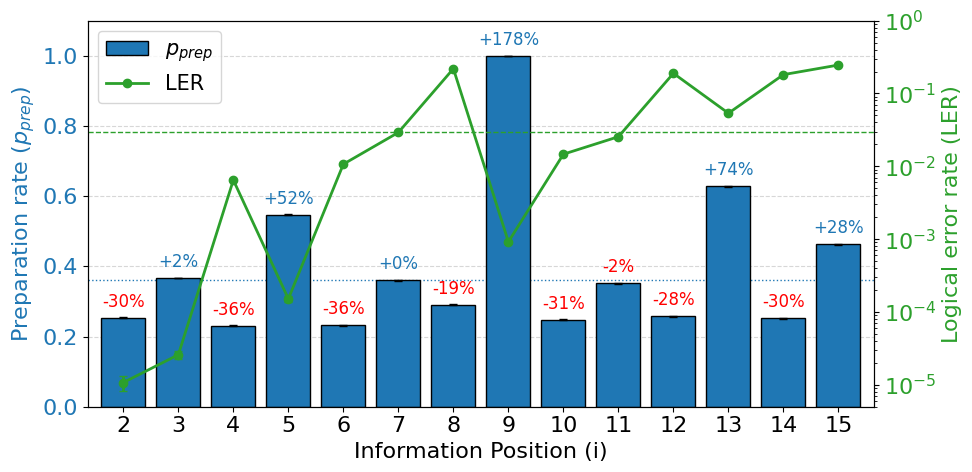

In [6]:
n_val = 4

# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n{n_val}_result/polar_results_json_normal_n{n_val}_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"

# p_error_val = 0.005
p_error_val = 0.01
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal"]
# i_val = [2, 3, 5, 9]
i_val = range(2, (2**n_val))
lstate_val = "x"

plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=5e-6, ler_ylim_max=1e-0) # 0.005


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
from matplotlib.container import BarContainer # Needed for BarContainer filtering

def plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), with percentage comparison between sim_types.
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['lstate'] == lstate_val)
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)
        
    # Get error columns
    # prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    prep_rate_error_col = "prep_rate_SD"
    # ler_error_col = get_error_col('LER', filtered_df.columns)
    ler_error_col = "LER_SD"

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---

    fig, ax1 = plt.subplots(figsize=(10, 5)) 
    # Adjusted Y-limit for annotation space
    ax1.set_ylim(0, 1.1) 

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    # Plotting the bars
    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # --- Plot LER Lines (Restored Logic) ---
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            ler_err = pivot_df_ler_err[sim_type].values
            x_line_coords = x_positions
            
            ler_line, _, _ = ax2.errorbar(
                x_line_coords, 
                ler_mean,
                yerr=ler_err, # Added yerr for LER plot
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

    # --- ANNOTATE COMPARISON: PROP-1 vs BASE ---

    # Get the BarContainers and Column names for comparison
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]
    
    if len(pivot_df_prep_rate.columns) >= 2:
        # Assuming the columns are sorted as Base (C1) and Prop-1 (C2)
        col_base = pivot_df_prep_rate.columns[0] 
        col_prop1 = pivot_df_prep_rate.columns[1] 
        
        if len(bar_containers) >= 2:
            # Prop-1 bar container is the second container (index 1)
            container_prop1 = bar_containers[1] 
            
            # Loop through the data points using the index (i)
            for i_idx, i_val in enumerate(pivot_df_prep_rate.index):
                val_base = pivot_df_prep_rate.loc[i_val, col_base]
                val_prop1 = pivot_df_prep_rate.loc[i_val, col_prop1]
                
                if val_base > 0:
                    pct_diff = ((val_prop1 - val_base) / val_base) * 100
                    
                    # Logic: Higher Prep is better (Green), Lower is worse (Red)
                    text_color = 'green' if pct_diff >= 0 else 'red'
                    sign = '+' if pct_diff >= 0 else '-'
                    
                    # Get the rectangle (bar) corresponding to this data point (i_idx)
                    rect = container_prop1[i_idx]
                    height = rect.get_height()
                    
                    # Place text above the Prop-1 bar
                    ax1.text(
                        rect.get_x() + rect.get_width() / 2, 
                        height + 0.02, # small offset
                        f"{sign}{abs(pct_diff):.1f}%", 
                        color=text_color, 
                        ha='center', 
                        va='bottom', 
                        fontsize=12, 
                        fontweight='bold',
                        zorder=4
                    )
    
    # --- Draw Baseline Lines (Restored Logic - assuming i=7 exists) ---
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            # 1. Prep Rate Baseline
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=0.8, 
                zorder=1,
                label='$p_{prep}$ baseline' # Note: label doesn't show in this setup
            )
            
            # 2. LER Baseline
            ler_color = ler_colors.get(sim_type, 'black')
            ax2.axhline(
                y=row['LER'],
                color=ler_color, 
                linestyle='--', 
                linewidth=0.8, 
                zorder=1,
                label=f'LER baseline' # Note: label doesn't show in this setup
            )

    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    # Fix: Integer X-Labels
    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends
    bar_handles = [c[0] for c in bar_containers] 
    
    # Labels adjusted for comparison names
    bar_labels = [
        "$p_{prep}$ - " + f"{l}"
        for l in pivot_df_prep_rate.columns
    ]

    ler_labels = [
        f"LER - {l}"
        for l in pivot_df_ler.columns
    ]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(
        combined_handles,
        combined_labels,
        loc='upper left',
        fontsize=15
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

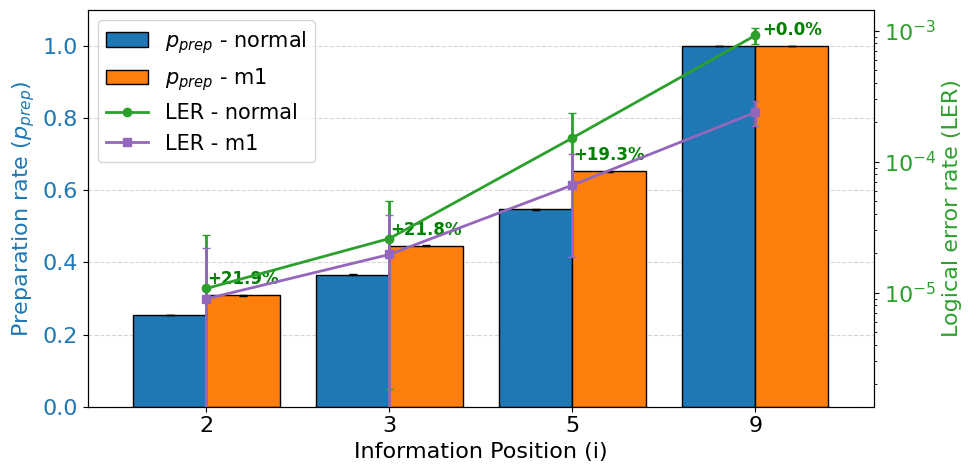

In [8]:
n_val = 4

# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n{n_val}_result/polar_results_json_normal_n{n_val}_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"

# p_error_val = 0.005
p_error_val = 0.01
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal", "m1"]
i_val = [2, 3, 5, 9]
lstate_val = "x"

# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.01
plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=5e-6, ler_ylim_max=1e-3) # 0.005
# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.005

In [9]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower left',
        bbox_to_anchor=(0.01, 0.25),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical error rate ($p$)')
    ax.set_ylabel('Preparation rate ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_n{n}_{lstate_values[0]}.png')
    plt.show()

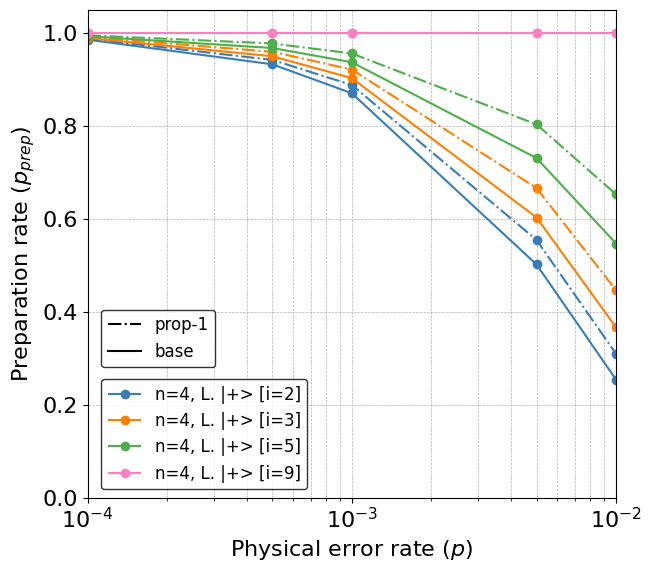

In [10]:
# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
n = [4]
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")



In [13]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png"):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 1e-10
    y_max_limit = 1e-2

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.85), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical error rate ($p$)')
    ax.set_ylabel('Preparation rate ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    plt.savefig(f'{out_path}polar_peler_n{n}_{lstate_values[0]}.png')
    plt.show()

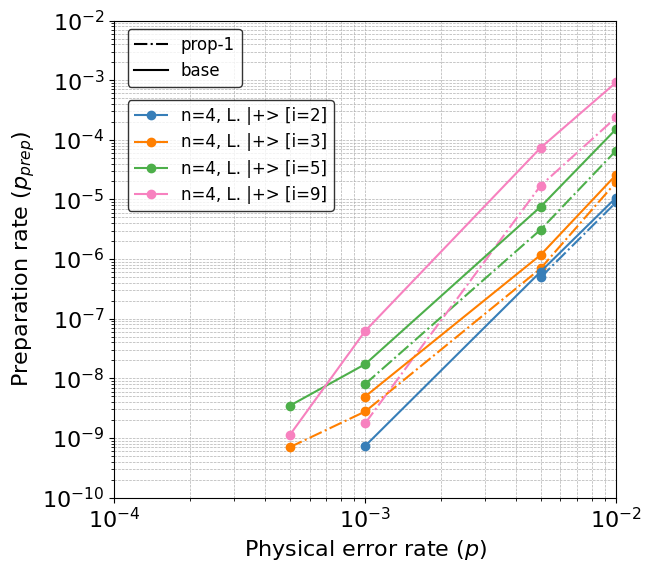

In [14]:
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
n = [4]
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["normal", "m1"]

create_figure_peler_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")



Adding horizontal baseline lines for i=7 values.


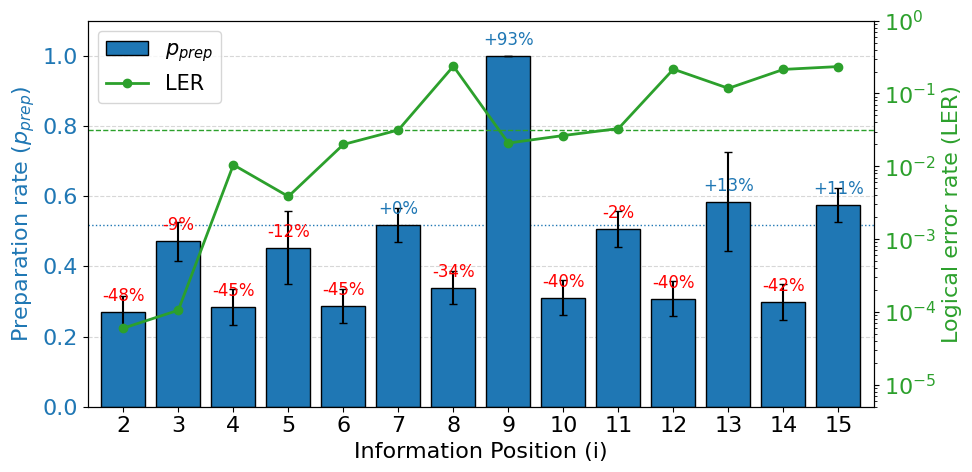

In [15]:
n_val = 4
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
p_error_val = 1
shots_val = 100
sim_type_val = ["normal"]
# i_val = [2, 3, 5, 9]
i_val = range(2, (2**n_val))
lstate_val = "x"

plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-0) # 0.005


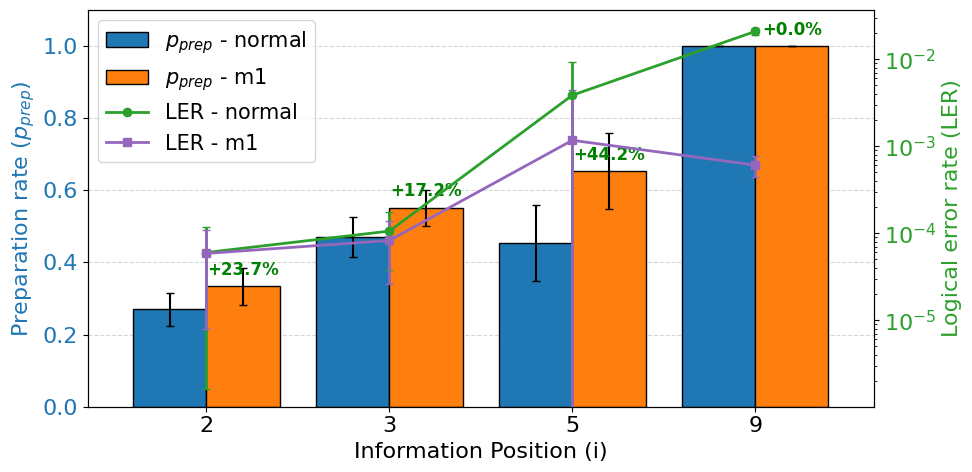

In [16]:
n_val = 4
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
p_error_val = 1
shots_val = 100
sim_type_val = ["normal", "m1"]
i_val = [2, 3, 5, 9]
lstate_val = "x"

plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-1) # 0.005


In [17]:
# 1. Define the helper function globally or at the beginning of the script
def get_error_col(rate_col, df_cols):
    """Checks for the presence of the SEM or SD column name for a given rate."""
    sem_col = f'{rate_col}_SEM'
    sd_col = f'{rate_col}_SD'
    if sem_col in df_cols:
        return sem_col
    elif sd_col in df_cols:
        return sd_col
    return None

def create_figure_peprep_accepted_qiskit(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering ---
    df = pd.read_csv(file_path)
    
    # 2. Determine the correct LER error column name
    # ler_error_col = get_error_col('prep_rate', df.columns)
    ler_error_col = "prep_rate_SEM"
    if not ler_error_col:
        print("Error: Could not find required LER error column (_SEM or _SD).")
        return
    
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    # Ensure the error column is available in the filtered data
    if ler_error_col not in filtered_df.columns:
        print(f"Error: Filtered data does not contain the determined error column: {ler_error_col}")
        return

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() 
    
    # Set scales explicitly before plotting.
    # Note: semilogy plots Y log and X linear.
    # ax.set_xscale('log') 
    # ax.set_yscale('log')
    
    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    data_handles = []
    data_labels = []
    sim_type_proxies = {} 
    
    # Placeholder for the filename to be correct if n_values is non-empty
    n_for_file = n_values[0] if n_values else 'N'
    lstate_for_file = lstate_values[0] if lstate_values else 'L'


    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, '-') 
        
        try:
            color_idx = i_values.index(i)
            color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]
        except ValueError:
            color_style = 'black'

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # 3. Use ax.errorbar for plotting with error bars
        # The 'fmt' argument combines marker and line style
        line, _, _ = ax.errorbar(
            group_df['p_error'],
            group_df['prep_rate'],
            yerr=group_df[ler_error_col], # <-- ERROR BARS integrated here
            fmt=f'{marker}{linestyle}',    # Combines marker and line (e.g., 'o-')
            fillstyle=marker_fill,
            color=color_style,
            capsize=3,                     # Size of the caps on the error bars
            label='_nolegend_',
            zorder=3
        )
        
        # Ensure we only get the line handle, not the error bars, for the legend
        if line.get_label() == '_nolegend_':
            # Remove line from legend if it was added automatically
            line.set_label(data_label) 
        
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        if str_sim_type not in sim_type_proxies:
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (e.g., for comparison, if needed)
    # Note: For log-log or linear-log plots, y=x line is often inappropriate.
    
    x_min_limit = 0
    x_max_limit = 1.02
    y_min_limit = 0
    y_max_limit = 1.02

    # 4. Create and Place Legends
    
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        loc='lower left',
        bbox_to_anchor=(0.01, 0),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    ax.add_artist(legend1)

    legend2 = ax.legend(
        data_handles,
        data_labels,
        loc='lower right',
        bbox_to_anchor=(1, 0.0), 
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling ---

    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    ax.set_xlabel(f'{hw_name} - scale error rate')
    ax.set_ylabel('Preparation rate ($p_{prep}$)') # Corrected Y-axis label

    ax.grid(True, which="both", ls="--", linewidth=0.5)

    plt.tight_layout()

    # Save the figure
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peler_n{n_for_file}_{lstate_for_file}.png')
    plt.show()

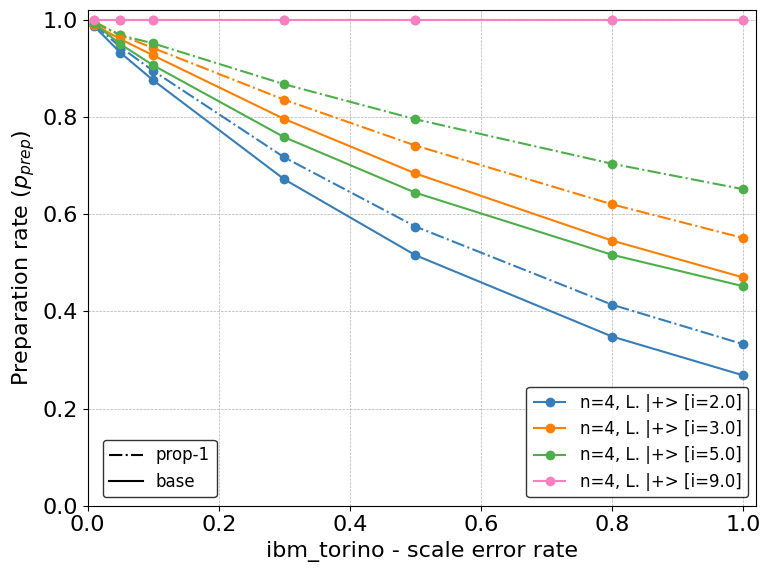

In [18]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/", hw_name=hw_name)



In [19]:
def create_figure_peler_accepted_qiskit(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering ---
    df = pd.read_csv(file_path)
    
    # 2. Determine the correct LER error column name
    ler_error_col = get_error_col('LER', df.columns)
    if not ler_error_col:
        print("Error: Could not find required LER error column (_SEM or _SD).")
        return
    
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    # Ensure the error column is available in the filtered data
    if ler_error_col not in filtered_df.columns:
        print(f"Error: Filtered data does not contain the determined error column: {ler_error_col}")
        return

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() 
    
    # Set scales explicitly before plotting.
    # Note: semilogy plots Y log and X linear.
    # ax.set_xscale('log') 
    ax.set_yscale('log')
    
    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    data_handles = []
    data_labels = []
    sim_type_proxies = {} 
    
    # Placeholder for the filename to be correct if n_values is non-empty
    n_for_file = n_values[0] if n_values else 'N'
    lstate_for_file = lstate_values[0] if lstate_values else 'L'


    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, '-') 
        
        try:
            color_idx = i_values.index(i)
            color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]
        except ValueError:
            color_style = 'black'

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # 3. Use ax.errorbar for plotting with error bars
        # The 'fmt' argument combines marker and line style
        line, _, _ = ax.errorbar(
            group_df['p_error'],
            group_df['LER'],
            yerr=group_df[ler_error_col], # <-- ERROR BARS integrated here
            fmt=f'{marker}{linestyle}',    # Combines marker and line (e.g., 'o-')
            fillstyle=marker_fill,
            color=color_style,
            capsize=3,                     # Size of the caps on the error bars
            label='_nolegend_',
            zorder=3
        )
        
        # Ensure we only get the line handle, not the error bars, for the legend
        if line.get_label() == '_nolegend_':
            # Remove line from legend if it was added automatically
            line.set_label(data_label) 
        
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        if str_sim_type not in sim_type_proxies:
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (e.g., for comparison, if needed)
    # Note: For log-log or linear-log plots, y=x line is often inappropriate.
    
    x_min_limit = 0
    x_max_limit = 1
    y_min_limit = 1e-9
    y_max_limit = 1e-1

    # 4. Create and Place Legends
    
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    ax.add_artist(legend1)

    legend2 = ax.legend(
        data_handles,
        data_labels,
        loc='lower right',
        bbox_to_anchor=(1, 0.0), 
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling ---

    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    ax.set_xlabel(f'{hw_name} - scale error rate')
    ax.set_ylabel('Logical Error Rate (LER)') # Corrected Y-axis label

    ax.grid(True, which="both", ls="--", linewidth=0.5)

    plt.tight_layout()

    # Save the figure
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peler_n{n_for_file}_{lstate_for_file}.png')
    plt.show()

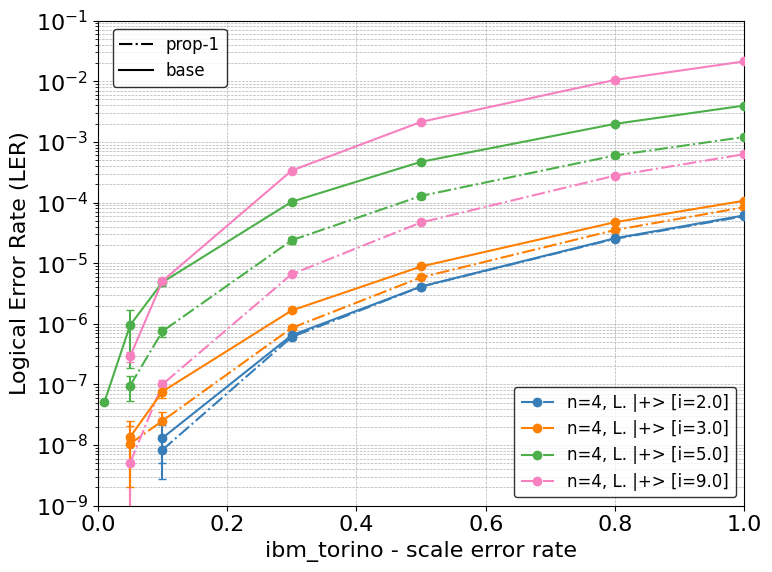

In [20]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["normal", "m1"]

create_figure_peler_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/", hw_name=hw_name)

